In [2]:
from matplotlib import pyplot as plt
import numpy as np
import math
import cmath
import scipy.signal as signal

/tmp/ipykernel_31032/2845378403.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([1e6, 1e7,1e8,1e9], fontsize=18)
/tmp/ipykernel_31032/2845378403.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=18)


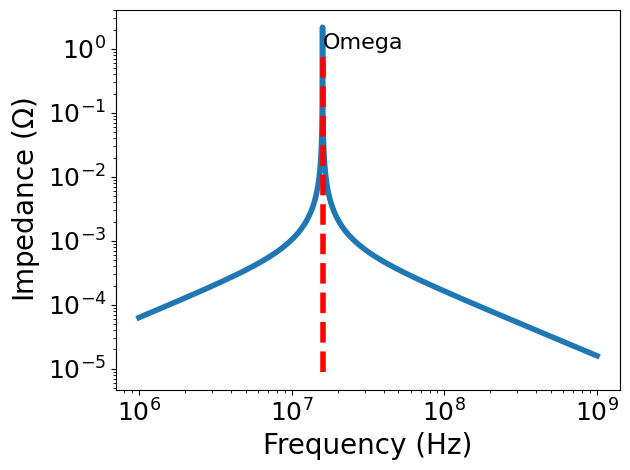

In [8]:
fig, ax = plt.subplots()
ax.set_ylabel("Impedance $(\\Omega)$", fontsize = 20)
ax.set_xlabel("Frequency (Hz)", fontsize = 20)

ax.set_xticklabels([1e6, 1e7,1e8,1e9], fontsize=18)
ax.set_yticklabels([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=18)


freq = np.logspace(6, 9, 10000)
capacitance = 10*10**(-(9-2))
inductance = 1*10**(-(9))
# Z_scl = 1/(1j*capacitance*10*freq*math.pi*2)+(1j*inductance/10000*2*math.pi*freq)
Z_pcl = 1/((1j*capacitance*10*freq*math.pi*2)+1/(1j*inductance/100*2*math.pi*freq))
# Z_c = 1/(1j*capacitance*freq*math.pi*2)
# Z_l = (1j*inductance*2*math.pi*freq)


lw = 4

# ax.set_ylim(1e-6, 1e0)

# ax.loglog(freq, abs(Z_scl), label = "I.", ls = '-', lw = lw)
ax.loglog(freq, abs(Z_pcl), label = "II.", ls = '-', lw = lw)
# ax.loglog(freq, abs(Z_c), label = "III.", ls = '-.', lw = lw+1)
# ax.loglog(freq, abs(Z_d_apr), label = "IV.", ls = ':', lw = lw+1)

peaks = signal.find_peaks(abs(Z_pcl))
ax.vlines([freq[peaks[0]]], ax.get_ylim()[0], 1, color='r', lw = lw, ls='--')
ax.text(freq[peaks[0]], 1, "Omega",fontdict={"size": 16})


# ax.legend(loc="upper right", framealpha=1)
plt.tight_layout()
fig.savefig(f"imp_par_lc", dpi=300, transparent=False, edgecolor="w", facecolor="w")


/tmp/ipykernel_27254/2130505281.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([1e6, 1e7,1e8,1e9], fontsize=18)
/tmp/ipykernel_27254/2130505281.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=18)


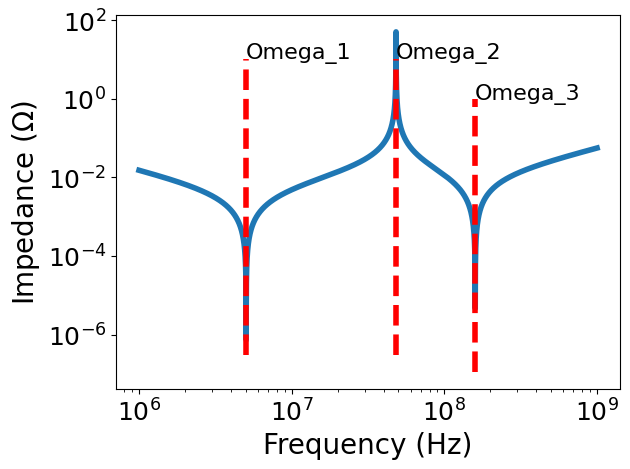

In [73]:
fig, ax = plt.subplots()
ax.set_ylabel("Impedance $(\\Omega)$", fontsize = 20)
ax.set_xlabel("Frequency (Hz)", fontsize = 20)

ax.set_xticklabels([1e6, 1e7,1e8,1e9], fontsize=18)
ax.set_yticklabels([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2], fontsize=18)


freq = np.logspace(6, 9, 10000)
capacitance = 10*10**(-(9-2))
inductance = 1*10**(-(9))
# Z_scl = 1/((1j*capacitance*10*freq*math.pi*2)+1/(1j*inductance/100*2*math.pi*freq))
Z_ser_left = 1/(1j*capacitance*10*freq*math.pi*2)+(1j*inductance/10*2*math.pi*freq)
Z_ser_right = 1/(1j*capacitance/10*freq*math.pi*2)+(1j*inductance/100*2*math.pi*freq)
Z_par = 1/(1/Z_ser_left + 1/Z_ser_right)

# Z_pcl = 1/((1j*capacitance*freq*math.pi*2)+1/(1j*inductance*2*math.pi*freq))
# Z_c = 1/(1j*capacitance*freq*math.pi*2)
# Z_l = (1j*inductance*2*math.pi*freq)


lw = 4


# ax.set_ylim(1e-6, 1e0)

ax.loglog(freq, abs(Z_par), label = "I.", ls = '-', lw = lw)
ax.vlines([freq[2339], freq[5610]], ax.get_ylim()[0], 10, color='r', lw = lw, ls='--')
ax.vlines([freq[7339]], ax.get_ylim()[0], 1, color='r', lw = lw, ls='--')
ax.text(freq[2339], 11, "Omega_1",fontdict={"size": 16})
ax.text(freq[5610], 11, "Omega_2",fontdict={"size": 16})
ax.text(freq[7339], 1, "Omega_3",fontdict={"size": 16})
# ax.loglog(freq, abs(Z_pcl), label = "II.", ls = '--', lw = lw)
# ax.loglog(freq, abs(Z_c), label = "III.", ls = '-.', lw = lw+1)
# ax.loglog(freq, abs(Z_d_apr), label = "IV.", ls = ':', lw = lw+1)

# ax.legend(loc="upper right", framealpha=1)
plt.tight_layout()
fig.savefig(f"imp_par_ser_lc", dpi=300, transparent=False, edgecolor="w", facecolor="w")


In [24]:
peaks = signal.find_peaks(-abs(Z_par))
peaks

# abs(Z_par[5610])
# freq[5610]/1e6

[2339, 5610, 7339]

(array([2339, 7339]), {})